# RQ14 — Direction Handling

## Research question

> Should CW and CCW Current-only acoustic decisions be modelled as separate physical domains, pooled blindly as one dataset, or pooled with explicit direction conditioning?

RQ13 established the frozen Current-only reference and showed a descriptive direction pattern that was not uniform across wheels:

- W1 was almost unchanged between directions;
- W2 was stronger in CCW;
- W4 was stronger in CW.

RQ14 tests the modelling consequence directly.

### Fixed factors

Everything below remains fixed:

- Dataset v1 B01–B07;
- password-level leave-one-password-out folds;
- Current movement only;
- recovered 695-D Absolute acoustic representation;
- one wheel at a time;
- logistic regression `C = 0.10`;
- complete 10-candidate within-scan ranking;
- no password/profile/repeat/ordinal/digit identifier metadata.

Only **direction handling** changes.

### Variants

**Separate**

Independent model for each `wheel × direction`.

This reproduces the RQ13 reference.

**Pooled-blind**

One model per wheel is trained on both CW and CCW candidates. Direction is not supplied.

If CW and CCW are just extra samples from one common acoustic mapping, this should improve or at least preserve performance.

**Direction-conditioned**

One model per wheel is trained on both directions, but direction is preserved as a known physical variable.

After the training-fold `StandardScaler`, the feature is expanded to:

\[
[z,\; d z]
\]

with `d = -1` for CCW and `+1` for CW.

This allows a shared acoustic component plus direction-dependent feature effects without creating two fully independent models.

### Supporting cross-direction transfer

A deliberately harder diagnostic trains only on one direction and tests the opposite direction:

- CCW → CW
- CW → CCW

This is not the primary model choice. It tests whether the two direction domains are acoustically interchangeable.

### Primary evaluation

The seven held-out passwords are the inferential units.

The RQ13 Separate result is the reference; Pooled-blind and Direction-conditioned are compared against it under the identical password folds.

## 1. Load and align B01–B07

In [47]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (
            p
            / "07_RQ7_Absolute_vs_Relative"
            / "RQ7_candidate_manifest.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate completed RQ7 manifest."
    )

MANIFEST_PATH = (
    RESULTS_ROOT
    / "07_RQ7_Absolute_vs_Relative"
    / "RQ7_candidate_manifest.csv"
)

CACHE_DIR = (
    RESULTS_ROOT
    / "feature_cache"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "14_RQ14_Direction_Handling"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BATCHES = [
    "B01_2085",
    "B02_4369",
    "B03_5720",
    "B04_6893",
    "B05_7246",
    "B06_8451",
    "B07_9638",
]

WHEELS = (
    1,
    2,
    4,
)

DIRECTIONS = (
    "CCW",
    "CW",
)

LOGREG_C = 0.10
RANDOM_STATE = 20260819

manifest = pd.read_csv(
    MANIFEST_PATH
)

if "row_id" not in manifest.columns:
    manifest[
        "row_id"
    ] = np.arange(
        len(
            manifest
        ),
        dtype=int,
    )

X = np.empty(
    (
        len(
            manifest
        ),
        695,
    ),
    dtype=np.float64,
)

for batch in BATCHES:
    cache_path = (
        CACHE_DIR
        / f"{batch}_695d.npz"
    )

    if not cache_path.exists():
        raise FileNotFoundError(
            cache_path
        )

    cache = np.load(
        cache_path,
        allow_pickle=False,
    )

    run_ids = cache[
        "run_ids"
    ].astype(str)

    features = cache[
        "features"
    ].astype(
        np.float64
    )

    index = {
        run_id: i
        for i, run_id
        in enumerate(
            run_ids
        )
    }

    batch_manifest = manifest[
        manifest[
            "batch"
        ]
        == batch
    ]

    rows = batch_manifest[
        "row_id"
    ].to_numpy(
        dtype=int
    )

    X[
        rows
    ] = np.vstack([
        features[
            index[
                run_id
            ]
        ]
        for run_id
        in batch_manifest[
            "run_id"
        ]
    ])

assert X.shape == (
    8400,
    695,
)

assert np.isfinite(
    X
).all()

direction_code = (
    manifest[
        "direction"
    ]
    .map({
        "CCW": -1.0,
        "CW": 1.0,
    })
    .to_numpy(
        dtype=float
    )
)

print(
    "Candidates:",
    len(
        manifest
    ),
)

print(
    "Decisions:",
    manifest[
        "decision_uid"
    ].nunique(),
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Candidates: 8400
Decisions: 840


## 2. Common training and ranking functions

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


def fit_score(
    train_idx,
    test_idx,
    conditioned=False,
):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X[
            train_idx
        ]
    )

    X_test = scaler.transform(
        X[
            test_idx
        ]
    )

    if conditioned:
        d_train = direction_code[
            train_idx
        ][
            :,
            None,
        ]

        d_test = direction_code[
            test_idx
        ][
            :,
            None,
        ]

        X_train = np.hstack([
            X_train,
            d_train
            * X_train,
        ])

        X_test = np.hstack([
            X_test,
            d_test
            * X_test,
        ])

    y_train = manifest.loc[
        train_idx,
        "y",
    ].to_numpy(
        dtype=int
    )

    model = LogisticRegression(
        C=LOGREG_C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    return model.decision_function(
        X_test
    )


def rank_decisions(
    part,
    score_col,
    model_name,
):
    rows = []

    for (
        decision_uid,
        group,
    ) in part.groupby(
        "decision_uid",
        sort=False,
    ):
        ranked = (
            group
            .sort_values(
                score_col,
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )

        true_digit = int(
            ranked[
                "true_digit"
            ].iloc[
                0
            ]
        )

        ranked_digits = (
            ranked[
                "to_digit"
            ]
            .astype(
                int
            )
            .tolist()
        )

        pred_digit = ranked_digits[
            0
        ]

        true_rank = (
            ranked_digits.index(
                true_digit
            )
            + 1
        )

        rows.append({
            "model": model_name,
            "heldout_batch": ranked[
                "batch"
            ].iloc[
                0
            ],
            "password": str(
                ranked[
                    "password"
                ].iloc[
                    0
                ]
            ),
            "decision_uid": (
                decision_uid
            ),
            "profile_id": ranked[
                "profile_id"
            ].iloc[
                0
            ],
            "wheel": int(
                ranked[
                    "wheel"
                ].iloc[
                    0
                ]
            ),
            "direction": ranked[
                "direction"
            ].iloc[
                0
            ],
            "repeat_id": ranked[
                "repeat_id"
            ].iloc[
                0
            ],
            "true_digit": (
                true_digit
            ),
            "pred_digit": int(
                pred_digit
            ),
            "true_rank": int(
                true_rank
            ),
            "top1": int(
                true_rank <= 1
            ),
            "top2": int(
                true_rank <= 2
            ),
            "top3": int(
                true_rank <= 3
            ),
            "reciprocal_rank": (
                1.0
                / true_rank
            ),
        })

    return pd.DataFrame(
        rows
    )


def metric_row(
    frame
):
    return {
        "n_decisions": len(
            frame
        ),
        "top1": frame[
            "top1"
        ].mean(),
        "top2": frame[
            "top2"
        ].mean(),
        "top3": frame[
            "top3"
        ].mean(),
        "mean_true_rank": frame[
            "true_rank"
        ].mean(),
        "median_true_rank": frame[
            "true_rank"
        ].median(),
        "mrr": frame[
            "reciprocal_rank"
        ].mean(),
        "macro_f1": f1_score(
            frame[
                "true_digit"
            ],
            frame[
                "pred_digit"
            ],
            labels=list(
                range(
                    10
                )
            ),
            average="macro",
            zero_division=0,
        ),
    }

## 3. Separate, pooled-blind and direction-conditioned LOPO

In [38]:
separate_parts = []
blind_parts = []
conditioned_parts = []

for heldout in BATCHES:
    # Separate direction models.
    for wheel in WHEELS:
        for direction in DIRECTIONS:
            domain = (
                manifest[
                    "wheel"
                ].eq(
                    wheel
                )
                &
                manifest[
                    "direction"
                ].eq(
                    direction
                )
            )

            train_mask = (
                domain
                &
                manifest[
                    "batch"
                ].ne(
                    heldout
                )
            )

            test_mask = (
                domain
                &
                manifest[
                    "batch"
                ].eq(
                    heldout
                )
            )

            train_idx = manifest.index[
                train_mask
            ].to_numpy()

            test_idx = manifest.index[
                test_mask
            ].to_numpy()

            scores = fit_score(
                train_idx,
                test_idx,
                conditioned=False,
            )

            part = manifest.loc[
                test_idx
            ].copy()

            part[
                "score"
            ] = scores

            separate_parts.append(
                rank_decisions(
                    part,
                    "score",
                    "Separate",
                )
            )

    # One wheel model with both directions.
    for wheel in WHEELS:
        domain = manifest[
            "wheel"
        ].eq(
            wheel
        )

        train_mask = (
            domain
            &
            manifest[
                "batch"
            ].ne(
                heldout
            )
        )

        test_mask = (
            domain
            &
            manifest[
                "batch"
            ].eq(
                heldout
            )
        )

        train_idx = manifest.index[
            train_mask
        ].to_numpy()

        test_idx = manifest.index[
            test_mask
        ].to_numpy()

        # Blind pooling.
        blind_scores = fit_score(
            train_idx,
            test_idx,
            conditioned=False,
        )

        blind_part = manifest.loc[
            test_idx
        ].copy()

        blind_part[
            "score"
        ] = blind_scores

        blind_parts.append(
            rank_decisions(
                blind_part,
                "score",
                "Pooled-blind",
            )
        )

        # Explicit direction conditioning.
        conditioned_scores = fit_score(
            train_idx,
            test_idx,
            conditioned=True,
        )

        conditioned_part = manifest.loc[
            test_idx
        ].copy()

        conditioned_part[
            "score"
        ] = conditioned_scores

        conditioned_parts.append(
            rank_decisions(
                conditioned_part,
                "score",
                "Direction-conditioned",
            )
        )


separate = pd.concat(
    separate_parts,
    ignore_index=True,
)

blind = pd.concat(
    blind_parts,
    ignore_index=True,
)

conditioned = pd.concat(
    conditioned_parts,
    ignore_index=True,
)

assert len(
    separate
) == 840

assert len(
    blind
) == 840

assert len(
    conditioned
) == 840

all_models = pd.concat(
    [
        separate,
        blind,
        conditioned,
    ],
    ignore_index=True,
)

display(
    all_models.head()
)

,model,heldout_batch,password,decision_uid,profile_id,wheel,direction,repeat_id,true_digit,pred_digit,true_rank,top1,top2,top3,reciprocal_rank
0,Separate,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_A,B01_W1_P01,1,CCW,A,2,7,2,0,1,1,0.500000
1,Separate,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_B,B01_W1_P01,1,CCW,B,2,3,3,0,0,1,0.333333
2,Separate,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_A,B01_W1_P02,1,CCW,A,2,3,4,0,0,0,0.250000
3,Separate,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_B,B01_W1_P02,1,CCW,B,2,1,5,0,0,0,0.200000
4,Separate,B01_2085,2085,B01_2085/B01_W1_P03_DSV1_MP2085_CCW_A,B01_W1_P03,1,CCW,A,2,2,1,1,1,1,1.000000


## 4. Cross-direction transfer diagnostic

In [39]:
cross_parts = []

for heldout in BATCHES:
    for wheel in WHEELS:
        for (
            train_direction,
            test_direction,
        ) in [
            (
                "CCW",
                "CW",
            ),
            (
                "CW",
                "CCW",
            ),
        ]:
            train_mask = (
                manifest[
                    "wheel"
                ].eq(
                    wheel
                )
                &
                manifest[
                    "direction"
                ].eq(
                    train_direction
                )
                &
                manifest[
                    "batch"
                ].ne(
                    heldout
                )
            )

            test_mask = (
                manifest[
                    "wheel"
                ].eq(
                    wheel
                )
                &
                manifest[
                    "direction"
                ].eq(
                    test_direction
                )
                &
                manifest[
                    "batch"
                ].eq(
                    heldout
                )
            )

            train_idx = manifest.index[
                train_mask
            ].to_numpy()

            test_idx = manifest.index[
                test_mask
            ].to_numpy()

            scores = fit_score(
                train_idx,
                test_idx,
                conditioned=False,
            )

            part = manifest.loc[
                test_idx
            ].copy()

            part[
                "score"
            ] = scores

            transfer_name = (
                f"{train_direction}"
                f"→{test_direction}"
            )

            ranked = rank_decisions(
                part,
                "score",
                transfer_name,
            )

            ranked[
                "train_direction"
            ] = (
                train_direction
            )

            ranked[
                "test_direction"
            ] = (
                test_direction
            )

            cross_parts.append(
                ranked
            )


cross = pd.concat(
    cross_parts,
    ignore_index=True,
)

assert len(
    cross
) == 840

display(
    cross.head()
)

,model,heldout_batch,password,decision_uid,profile_id,wheel,direction,repeat_id,true_digit,pred_digit,true_rank,top1,top2,top3,reciprocal_rank,train_direction,test_direction
0,CCW→CW,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CW_A,B01_W1_P01,1,CW,A,2,9,3,0,0,1,0.333333,CCW,CW
1,CCW→CW,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CW_B,B01_W1_P01,1,CW,B,2,2,1,1,1,1,1.000000,CCW,CW
2,CCW→CW,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CW_A,B01_W1_P02,1,CW,A,2,2,1,1,1,1,1.000000,CCW,CW
3,CCW→CW,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CW_B,B01_W1_P02,1,CW,B,2,8,3,0,0,1,0.333333,CCW,CW
4,CCW→CW,B01_2085,2085,B01_2085/B01_W1_P03_DSV1_MP2085_CW_A,B01_W1_P03,1,CW,A,2,2,1,1,1,1,1.000000,CCW,CW


## 5. Summary and password-level tests

In [40]:
from scipy.stats import wilcoxon

summary_rows = []

for (
    model,
    group,
) in all_models.groupby(
    "model",
    sort=False,
):
    summary_rows.append({
        "scope": "Overall",
        "model": model,
        **metric_row(
            group
        ),
    })

    for wheel in WHEELS:
        summary_rows.append({
            "scope": (
                f"W{wheel}"
            ),
            "model": model,
            **metric_row(
                group[
                    group[
                        "wheel"
                    ]
                    == wheel
                ]
            ),
        })

    for direction in DIRECTIONS:
        summary_rows.append({
            "scope": (
                direction
            ),
            "model": (
                model
            ),
            **metric_row(
                group[
                    group[
                        "direction"
                    ]
                    == direction
                ]
            ),
        })


summary = pd.DataFrame(
    summary_rows
)


password_summary = (
    all_models.groupby(
        [
            "model",
            "heldout_batch",
            "password",
        ],
        sort=False,
    )
    .apply(
        lambda g: pd.Series(
            metric_row(
                g
            )
        ),
        include_groups=False,
    )
    .reset_index()
)


wheel_summary = (
    all_models.groupby(
        [
            "model",
            "wheel",
        ],
        sort=False,
    )
    .apply(
        lambda g: pd.Series(
            metric_row(
                g
            )
        ),
        include_groups=False,
    )
    .reset_index()
)


direction_summary = (
    all_models.groupby(
        [
            "model",
            "direction",
        ],
        sort=False,
    )
    .apply(
        lambda g: pd.Series(
            metric_row(
                g
            )
        ),
        include_groups=False,
    )
    .reset_index()
)


cross_summary = (
    cross.groupby(
        [
            "wheel",
            "train_direction",
            "test_direction",
        ]
    )
    .apply(
        lambda g: pd.Series(
            metric_row(
                g
            )
        ),
        include_groups=False,
    )
    .reset_index()
)


password_wide = (
    password_summary.pivot(
        index=[
            "heldout_batch",
            "password",
        ],
        columns="model",
        values="top1",
    )
    .reset_index()
)


test_rows = []

for comparator in [
    "Pooled-blind",
    "Direction-conditioned",
]:
    difference = (
        password_wide[
            comparator
        ]
        - password_wide[
            "Separate"
        ]
    )

    greater = wilcoxon(
        password_wide[
            comparator
        ],
        password_wide[
            "Separate"
        ],
        alternative="greater",
        method="auto",
    )

    two_sided = wilcoxon(
        password_wide[
            comparator
        ],
        password_wide[
            "Separate"
        ],
        alternative="two-sided",
        method="auto",
    )

    test_rows.append({
        "comparison": (
            f"{comparator} "
            "vs Separate"
        ),
        "n_passwords": len(
            password_wide
        ),
        "mean_delta_pp": float(
            100
            * difference.mean()
        ),
        "median_delta_pp": float(
            100
            * difference.median()
        ),
        "comparator_better_passwords": int(
            (
                difference
                > 0
            ).sum()
        ),
        "equal_passwords": int(
            (
                difference
                == 0
            ).sum()
        ),
        "separate_better_passwords": int(
            (
                difference
                < 0
            ).sum()
        ),
        "p_one_sided_comparator_better": float(
            greater.pvalue
        ),
        "p_two_sided": float(
            two_sided.pvalue
        ),
    })


tests = pd.DataFrame(
    test_rows
)

display(
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ].round(
        4
    )
)

display(
    wheel_summary.round(
        4
    )
)

display(
    tests.round(
        4
    )
)

,scope,model,n_decisions,top1,top2,top3,mean_true_rank,median_true_rank,mrr,macro_f1
0,Overall,Separate,840,0.7857,0.9036,0.9548,1.4048,1.0,0.8712,0.7809
6,Overall,Pooled-blind,840,0.7214,0.8726,0.9369,1.5333,1.0,0.8317,0.7132
12,Overall,Direction-conditioned,840,0.7310,0.8798,0.9393,1.5250,1.0,0.8376,0.7297


,model,wheel,n_decisions,top1,top2,top3,mean_true_rank,median_true_rank,mrr,macro_f1
0,Separate,1,280.0,0.7250,0.8607,0.9321,1.5607,1.0,0.8306,0.5234
1,Separate,2,280.0,0.7714,0.8786,0.9429,1.4714,1.0,0.8584,0.5575
2,Separate,4,280.0,0.8607,0.9714,0.9893,1.1821,1.0,0.9245,0.6155
3,Pooled-blind,1,280.0,0.7143,0.8679,0.9357,1.5250,1.0,0.8280,0.5220
4,Pooled-blind,2,280.0,0.6964,0.8429,0.9107,1.6821,1.0,0.8096,0.5085
5,Pooled-blind,4,280.0,0.7536,0.9071,0.9643,1.3929,1.0,0.8575,0.5530
6,Direction-conditioned,1,280.0,0.6750,0.8571,0.9036,1.6750,1.0,0.8017,0.4814
7,Direction-conditioned,2,280.0,0.7107,0.8571,0.9321,1.6036,1.0,0.8220,0.5213
8,Direction-conditioned,4,280.0,0.8071,0.9250,0.9821,1.2964,1.0,0.8891,0.5839


,comparison,n_passwords,mean_delta_pp,median_delta_pp,comparator_better_passwords,equal_passwords,separate_better_passwords,p_one_sided_comparator_better,p_two_sided
0,Pooled-blind vs Separate,7,-6.4286,-5.8333,0,0,7,1.0,0.0156
1,Direction-conditioned vs Separate,7,-5.4762,-5.0000,0,1,6,1.0,0.0312


## 6. Main figures

In [41]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

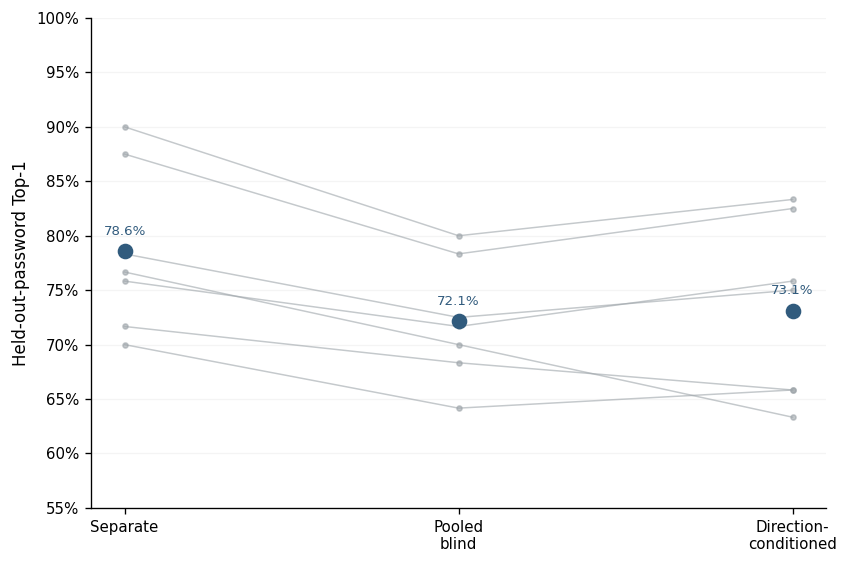

In [42]:
# Figure 1 — seven held-out-password trajectories across direction handling.

model_order = [
    "Separate",
    "Pooled-blind",
    "Direction-conditioned",
]

model_x = np.arange(
    len(
        model_order
    )
)

fig, ax = plt.subplots(
    figsize=(
        7.2,
        4.8,
    )
)

for (
    password,
    group,
) in password_summary.groupby(
    "password",
    sort=False,
):
    row = (
        group
        .set_index(
            "model"
        )
        .reindex(
            model_order
        )
    )

    ax.plot(
        model_x,
        100
        * row[
            "top1"
        ].to_numpy(),
        color=MID_GREY,
        linewidth=0.9,
        alpha=0.60,
        marker="o",
        markersize=3,
    )


mean_by_model = (
    password_summary.groupby(
        "model"
    )[
        "top1"
    ]
    .mean()
    .reindex(
        model_order
    )
)

ax.scatter(
    model_x,
    100
    * mean_by_model.to_numpy(),
    s=70,
    color=DARK_BLUE,
    zorder=4,
)

for (
    xi,
    value,
) in zip(
    model_x,
    100
    * mean_by_model.to_numpy(),
):
    ax.annotate(
        f"{value:.1f}%",
        xy=(
            xi,
            value,
        ),
        xytext=(
            0,
            10,
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color=DARK_BLUE,
    )


ax.set_xticks(
    model_x
)

ax.set_xticklabels([
    "Separate",
    "Pooled\nblind",
    "Direction-\nconditioned",
])

ax.set_ylabel(
    "Held-out-password Top-1"
)

ax.set_ylim(
    55,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ14_Fig1_password_direction_handling",
)

plt.show()

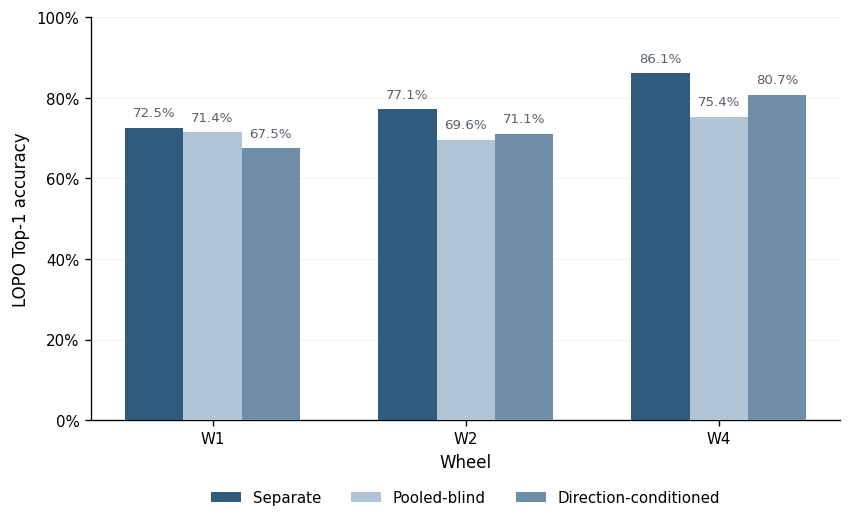

In [43]:
# Figure 2 — wheel-level effect of direction handling.

wheel_plot = (
    wheel_summary.pivot(
        index="wheel",
        columns="model",
        values="top1",
    )
    .reindex(
        index=[
            1,
            2,
            4,
        ],
        columns=[
            "Separate",
            "Pooled-blind",
            "Direction-conditioned",
        ],
    )
)

fig, ax = plt.subplots(
    figsize=(
        7.2,
        4.4,
    )
)

x = np.arange(
    3
)

bar_width = 0.23

colors = {
    "Separate": DARK_BLUE,
    "Pooled-blind": LIGHT_BLUE,
    "Direction-conditioned": MID_BLUE,
}

offsets = {
    "Separate": -bar_width,
    "Pooled-blind": 0.0,
    "Direction-conditioned": bar_width,
}

for model in [
    "Separate",
    "Pooled-blind",
    "Direction-conditioned",
]:
    values = (
        100
        * wheel_plot[
            model
        ].to_numpy()
    )

    bars = ax.bar(
        x
        + offsets[
            model
        ],
        values,
        width=bar_width,
        color=colors[
            model
        ],
        edgecolor="none",
        label=model,
        zorder=3,
    )

    for (
        bar,
        value,
    ) in zip(
        bars,
        values,
    ):
        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_x()
                + bar.get_width()
                / 2,
                bar.get_height(),
            ),
            xytext=(
                0,
                5,
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color=DARK_GREY,
        )

ax.set_xticks(
    x
)

ax.set_xticklabels([
    "W1",
    "W2",
    "W4",
])

ax.set_xlabel(
    "Wheel"
)

ax.set_ylabel(
    "LOPO Top-1 accuracy"
)

ax.set_ylim(
    0,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.14,
    ),
)

fig.subplots_adjust(
    bottom=0.22
)

fig.tight_layout()

save_figure(
    fig,
    "RQ14_Fig2_wheel_direction_handling",
)

plt.show()

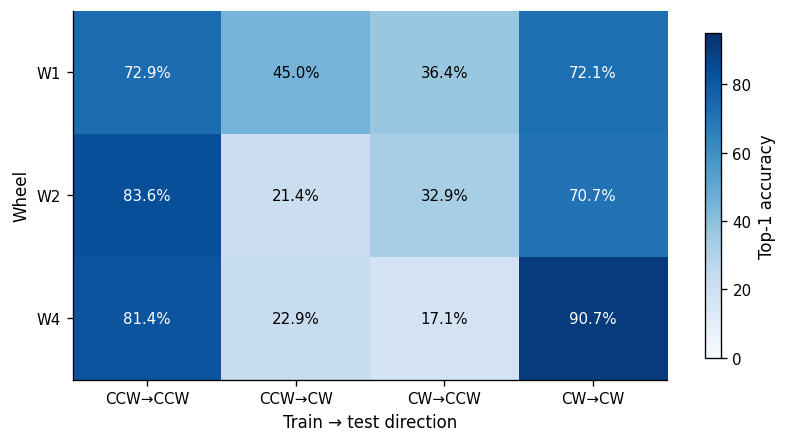

In [44]:
# Figure 3 — supporting cross-direction transfer diagnostic.

same_direction_rows = []

for wheel in WHEELS:
    for direction in DIRECTIONS:
        frame = separate[
            (
                separate[
                    "wheel"
                ]
                == wheel
            )
            &
            (
                separate[
                    "direction"
                ]
                == direction
            )
        ]

        same_direction_rows.append({
            "wheel": wheel,
            "train_direction": direction,
            "test_direction": direction,
            **metric_row(
                frame
            ),
        })


same_direction_summary = pd.DataFrame(
    same_direction_rows
)

transfer_matrix_summary = pd.concat(
    [
        same_direction_summary,
        cross_summary,
    ],
    ignore_index=True,
)


columns = [
    "CCW→CCW",
    "CCW→CW",
    "CW→CCW",
    "CW→CW",
]

rows = []

for wheel in WHEELS:
    values = []

    for (
        train_d,
        test_d,
    ) in [
        (
            "CCW",
            "CCW",
        ),
        (
            "CCW",
            "CW",
        ),
        (
            "CW",
            "CCW",
        ),
        (
            "CW",
            "CW",
        ),
    ]:
        row = transfer_matrix_summary[
            (
                transfer_matrix_summary[
                    "wheel"
                ]
                == wheel
            )
            &
            (
                transfer_matrix_summary[
                    "train_direction"
                ]
                == train_d
            )
            &
            (
                transfer_matrix_summary[
                    "test_direction"
                ]
                == test_d
            )
        ].iloc[
            0
        ]

        values.append(
            100
            * row[
                "top1"
            ]
        )

    rows.append(
        values
    )


transfer_matrix = np.array(
    rows
)

fig, ax = plt.subplots(
    figsize=(
        7.0,
        3.8,
    )
)

image = ax.imshow(
    transfer_matrix,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=95,
)

ax.set_xticks(
    np.arange(
        len(
            columns
        )
    )
)

ax.set_xticklabels(
    columns
)

ax.set_yticks(
    np.arange(
        3
    )
)

ax.set_yticklabels([
    "W1",
    "W2",
    "W4",
])

ax.set_xlabel(
    "Train → test direction"
)

ax.set_ylabel(
    "Wheel"
)

for i in range(
    transfer_matrix.shape[
        0
    ]
):
    for j in range(
        transfer_matrix.shape[
            1
        ]
    ):
        value = transfer_matrix[
            i,
            j,
        ]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
            color=(
                "white"
                if value
                >= 58
                else "black"
            ),
        )


cbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.88,
)

cbar.set_label(
    "Top-1 accuracy"
)

fig.tight_layout()

save_figure(
    fig,
    "RQ14_Fig3_cross_direction_transfer",
)

transfer_matrix_summary.to_csv(
    RESULT_DIR
    / "RQ14_cross_direction_summary.csv",
    index=False,
)

plt.show()

## 7. Tables and result record

In [45]:
all_models.to_csv(
    RESULT_DIR
    / "RQ14_decision_predictions.csv",
    index=False,
)

cross.to_csv(
    RESULT_DIR
    / "RQ14_cross_direction_predictions.csv",
    index=False,
)

summary.to_csv(
    RESULT_DIR
    / "RQ14_summary_metrics.csv",
    index=False,
)

password_summary.to_csv(
    RESULT_DIR
    / "RQ14_password_summary.csv",
    index=False,
)

wheel_summary.to_csv(
    RESULT_DIR
    / "RQ14_wheel_summary.csv",
    index=False,
)

direction_summary.to_csv(
    RESULT_DIR
    / "RQ14_direction_summary.csv",
    index=False,
)

tests.to_csv(
    RESULT_DIR
    / "RQ14_password_level_tests.csv",
    index=False,
)


table1 = summary[
    summary[
        "scope"
    ]
    == "Overall"
].copy()

for (
    source_col,
    output_col,
) in [
    (
        "top1",
        "Top-1",
    ),
    (
        "top2",
        "Top-2",
    ),
    (
        "top3",
        "Top-3",
    ),
]:
    table1[
        output_col
    ] = (
        100
        * table1[
            source_col
        ]
    ).map(
        lambda x: f"{x:.1f}%"
    )


table1[
    "Mean rank"
] = table1[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table1 = table1[
    [
        "model",
        "n_decisions",
        "Top-1",
        "Top-2",
        "Top-3",
        "Mean rank",
    ]
].rename(
    columns={
        "model": (
            "Direction handling"
        ),
        "n_decisions": (
            "N decisions"
        ),
    }
)

table1.to_csv(
    RESULT_DIR
    / "RQ14_Table1_direction_handling.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ14_Table1_direction_handling.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = cross_summary.copy()

table2[
    "Top-1"
] = (
    100
    * table2[
        "top1"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Mean rank"
] = table2[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table2 = table2[
    [
        "wheel",
        "train_direction",
        "test_direction",
        "n_decisions",
        "Top-1",
        "Mean rank",
    ]
].rename(
    columns={
        "wheel": "Wheel",
        "train_direction": (
            "Train direction"
        ),
        "test_direction": (
            "Test direction"
        ),
        "n_decisions": (
            "N decisions"
        ),
    }
)

table2.to_csv(
    RESULT_DIR
    / "RQ14_Table2_cross_direction.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ14_Table2_cross_direction.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    table2
)

,Direction handling,N decisions,Top-1,Top-2,Top-3,Mean rank
0,Separate,840,78.6%,90.4%,95.5%,1.40
6,Pooled-blind,840,72.1%,87.3%,93.7%,1.53
12,Direction-conditioned,840,73.1%,88.0%,93.9%,1.52


,Wheel,Train direction,Test direction,N decisions,Top-1,Mean rank
0,1,CCW,CW,140.0,45.0%,2.19
1,1,CW,CCW,140.0,36.4%,3.29
2,2,CCW,CW,140.0,21.4%,3.43
3,2,CW,CCW,140.0,32.9%,3.46
4,4,CCW,CW,140.0,22.9%,4.01
5,4,CW,CCW,140.0,17.1%,4.22


In [46]:
overall_models = (
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ]
    .set_index(
        "model"
    )
)

sep_top1 = float(
    overall_models.loc[
        "Separate",
        "top1",
    ]
)

blind_top1 = float(
    overall_models.loc[
        "Pooled-blind",
        "top1",
    ]
)

cond_top1 = float(
    overall_models.loc[
        "Direction-conditioned",
        "top1",
    ]
)


conclusion = {
    "research_question": (
        "Should CW and CCW Current-only acoustic decisions be modelled separately, "
        "naively pooled, or pooled with explicit direction conditioning?"
    ),
    "analysis_type": (
        "Controlled direction-handling ablation under identical B01-B07 password-LOPO folds"
    ),
    "fixed_factors": [
        "Current movement only",
        "Absolute recovered 695-D feature representation",
        "Logistic regression C=0.10",
        "Separate wheel domains",
        "Complete 10-candidate within-scan ranking",
        "RQ12 password-grouped evaluation",
    ],
    "overall": {
        "Separate_top1": sep_top1,
        "Pooled_blind_top1": blind_top1,
        "Direction_conditioned_top1": cond_top1,
    },
    "password_level_tests": (
        tests.to_dict(
            orient="records"
        )
    ),
    "wheel_results": (
        wheel_summary.to_dict(
            orient="records"
        )
    ),
    "cross_direction_results": (
        cross_summary.to_dict(
            orient="records"
        )
    ),
    "selected_variant": "Separate",
    "interpretation": (
        f"Direction handling has a clear effect and the effect is wheel-dependent rather than "
        f"one direction being globally superior. The Separate RQ13 reference achieves "
        f"{100 * sep_top1:.1f}% Top-1. Naive direction-blind pooling falls to "
        f"{100 * blind_top1:.1f}% and is worse across the held-out passwords. The fixed "
        f"full-feature direction-conditioned model reaches {100 * cond_top1:.1f}% and still "
        f"does not match Separate. Cross-direction transfer is much weaker than matched-direction "
        f"evaluation, especially for W2 and W4. CW and CCW therefore behave as distinct acoustic "
        f"domains rather than interchangeable extra samples."
    ),
    "limitation": (
        "The conditioned model uses one fixed interaction form [z, direction × z] "
        "and does not tune a direction weight. This RQ tests modelling of direction, "
        "not physical score fusion between two direction scans from the same profile."
    ),
    "decision": (
        "Select Separate wheel × direction models as the fixed direction treatment for the "
        "next controlled ablations. Do not use direction-blind pooling. Retain direction-conditioned "
        "modelling only as a later architecture option that may be revisited with feature selection "
        "or shared-model regularisation."
    ),
    "next_step": (
        "The next controlled ablation tests A-only vs B-only vs A+B / repeat fusion "
        "while preserving the direction treatment established here."
    ),
}

with open(
    RESULT_DIR
    / "RQ14_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "14_RQ14_Direction_Handling.ipynb"
    ),
    "source": (
        "B01-B07 frozen 695-D feature caches + RQ7 candidate manifest"
    ),
    "passwords": 7,
    "candidates": 8400,
    "decisions": 840,
    "C": LOGREG_C,
    "variants": [
        "Separate",
        "Pooled-blind",
        "Direction-conditioned",
        "Cross-direction transfer",
    ],
    "direction_encoding": {
        "CCW": -1,
        "CW": 1,
    },
    "conditioned_expansion": (
        "[standardised z, direction × standardised z]"
    ),
    "primary_metric": (
        "Password-grouped LOPO Top-1"
    ),
}


with open(
    RESULT_DIR
    / "RQ14_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ14_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Should CW and CCW Current-only acoustic decisions be modelled separately, naively pooled, or pooled with explicit direction conditioning?",
  "analysis_type": "Controlled direction-handling ablation under identical B01-B07 password-LOPO folds",
  "fixed_factors": [
    "Current movement only",
    "Absolute recovered 695-D feature representation",
    "Logistic regression C=0.10",
    "Separate wheel domains",
    "Complete 10-candidate within-scan ranking",
    "RQ12 password-grouped evaluation"
  ],
  "overall": {
    "Separate_top1": 0.7857142857142857,
    "Pooled_blind_top1": 0.7214285714285714,
    "Direction_conditioned_top1": 0.7309523809523809
  },
  "password_level_tests": [
    {
      "comparison": "Pooled-blind vs Separate",
      "n_passwords": 7,
      "mean_delta_pp": -6.428571428571428,
      "median_delta_pp": -5.833333333333335,
      "comparator_better_passwords": 0,
      "equal_passwords": 0,
      "separate_better_passwords": 7,
      "p